## **Pipeline**

#### **Required Libraries**

In [ ]:
import nltk
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

#### **IMDB Dataset**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
df = pd.read_csv("/content/IMDB Dataset.csv")

In [ ]:
print("Shape of Dataset : \n",df.shape)
print("Size of Dataset : \n",df.size)

Shape of Dataset : 
 (50000, 2)
Size of Dataset : 
 100000


In [ ]:
print("Columns in Dataset : \n",df.columns)

Columns in Dataset : 
 Index(['review', 'sentiment'], dtype='object')


In [ ]:
print("Description of Dataset : \n",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
Description of Dataset : 
 None


In [ ]:
print("Null Values Present in Dataset : \n",df.isnull().sum())

Null Values Present in Dataset : 
 review       0
sentiment    0
dtype: int64


In [ ]:
print("Dupliacted Values in Dataest : \n",df.duplicated().sum())

Dupliacted Values in Dataest : 
 418


In [ ]:
# To Drop Dupliated Values
df = df.drop_duplicates()

In [ ]:
# Shape and Size of Dataset after removal of Duplicate values
print("Shape of Dataset : \n",df.shape)
print("Size of Dataset : \n",df.size)

Shape of Dataset : 
 (49582, 2)
Size of Dataset : 
 99164


In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#### **Data Preprocessing**

In [ ]:
import re

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [ ]:
def text_preprocess (text) -> str :
  text = text.lower()
  text = re.sub(r"[^a-zA-Z0-9]"," ",text)
  words = word_tokenize(text)
  words = [lemmatizer.lemmatize(word,pos = "v") for word in words]
  words = [word for word in words if word not in stop_words]

  text = " ".join(words)
  return text

In [ ]:
df["Cleaned_Review"] = df["review"].apply(text_preprocess)

In [ ]:
df.head()

,review,sentiment,Cleaned_Review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mention watch 1 oz episode hook ...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br film techniq...
2,I thought this was a wonderful way to spend ti...,positive,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stun fi...


#### **Feature and Target Value Selection**

In [ ]:
x = df["Cleaned_Review"].values
y = df["sentiment"].values

#### **Vectorization**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
cv = CountVectorizer(max_features = 5000)
x_cv = cv.fit_transform(x).toarray()

In [ ]:
print("Input Feature Vectors (CountVectorizer) : \n",x_cv)
print("Shape of Input Features : ",x_cv.shape)

Input Feature Vectors (CountVectorizer) : 
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Shape of Input Features :  (49582, 5000)


In [ ]:
tfidf = TfidfVectorizer(max_features = 5000)
x_tf = tfidf.fit_transform(x).toarray()

In [ ]:
print("Input Feature Vectors (TfidfVectorizer) : \n",x_tf)
print("Shape of Input Features : ",x_tf.shape)

Input Feature Vectors (TfidfVectorizer) : 
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Shape of Input Features :  (49582, 5000)


### **CountVectorizer Implementation**

#### **Train - Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_cv,y,test_size = 0.2,
                                                 random_state = 42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(39665, 5000)
(39665,)
(9917, 5000)
(9917,)


#### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model = LogisticRegression(max_iter = 5000)
log_model.fit(x_train,y_train)

LogisticRegression(max_iter=5000)

In [ ]:
prdt_train = log_model.predict(x_train)
prdt_test = log_model.predict(x_test)

print("Predictions on Training Data : ",prdt_train)
print("Predictions on Testing Data : ",prdt_test)

Predictions on Training Data :  ['negative' 'negative' 'positive' ... 'negative' 'positive' 'positive']
Predictions on Testing Data :  ['negative' 'positive' 'positive' ... 'negative' 'negative' 'negative']


In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train,prdt_train)
acc_test = accuracy_score(y_test,prdt_test)

print("Accuracy on Training Data : ",acc_train)
print("Accuracy on Testing Data : ",acc_test)

Accuracy on Training Data :  0.9371738308332282
Accuracy on Testing Data :  0.8675002520923667


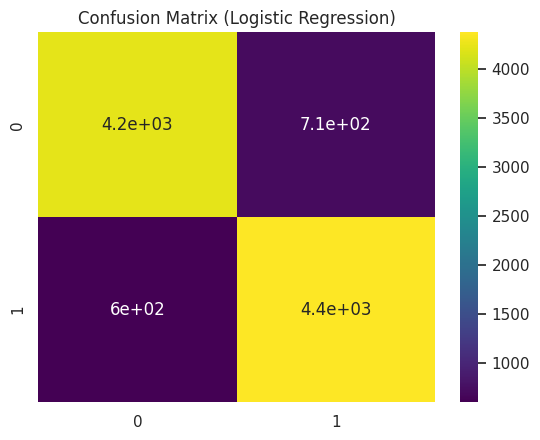

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cf = confusion_matrix(y_test,prdt_test)
sns.set_theme()

sns.heatmap(cf,cmap = "viridis",annot = True)
plt.title("Confusion Matrix (Logistic Regression)")

plt.show()

In [ ]:
cr = classification_report(y_test,prdt_test)
print("Classification Report (Logistic Regression) : \n",cr)

Classification Report (Logistic Regression) : 
               precision    recall  f1-score   support

    negative       0.88      0.86      0.87      4939
    positive       0.86      0.88      0.87      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



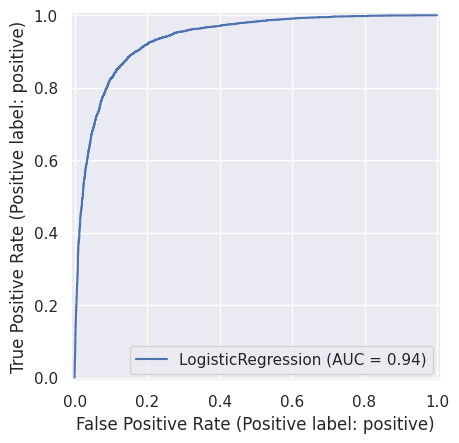

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(log_model,x_test,y_test)

plt.grid(True)
plt.show()

#### **Multinomial Naive Bayes**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
mb = MultinomialNB()
mb.fit(x_train,y_train)

MultinomialNB()

In [ ]:
prdt_train = mb.predict(x_train)
prdt_test = mb.predict(x_test)

print("Predictions on Training Data : ",prdt_train)
print("Predictions on Testing Data : ",prdt_test)

Predictions on Training Data :  ['negative' 'negative' 'positive' ... 'negative' 'positive' 'positive']
Predictions on Testing Data :  ['negative' 'positive' 'positive' ... 'negative' 'positive' 'negative']


In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train,prdt_train)
acc_test = accuracy_score(y_test,prdt_test)

print("Accuracy on Training Data : ",acc_train)
print("Accuracy on Testing Data : ",acc_test)

Accuracy on Training Data :  0.8538510021429472
Accuracy on Testing Data :  0.8462236563476858


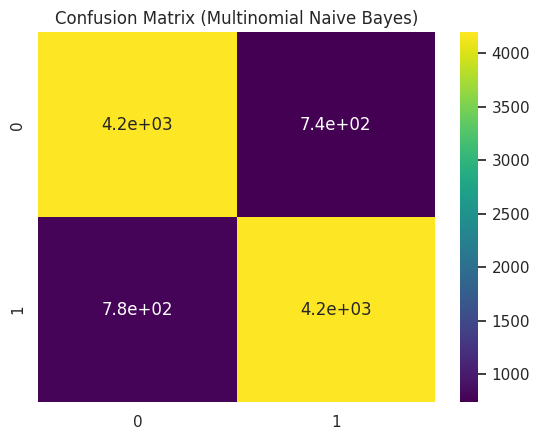

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cf = confusion_matrix(y_test,prdt_test)
sns.set_theme()

sns.heatmap(cf,cmap = "viridis",annot = True)
plt.title("Confusion Matrix (Multinomial Naive Bayes)")

plt.show()

In [ ]:
cr = classification_report(y_test,prdt_test)
print("Classification Report (Multinomial Naive Bayes) : \n",cr)

Classification Report (Multinomial Naive Bayes) : 
               precision    recall  f1-score   support

    negative       0.84      0.85      0.85      4939
    positive       0.85      0.84      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



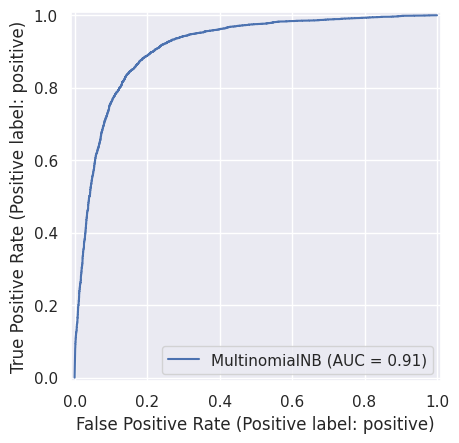

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(mb,x_test,y_test)

plt.grid(True)
plt.show()

#### **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
prdt_train = rf.predict(x_train)
prdt_test = rf.predict(x_test)

print("Predictions on Training Data : ",prdt_train)
print("Predictions on Testing Data : ",prdt_test)

Predictions on Training Data :  ['negative' 'negative' 'positive' ... 'negative' 'positive' 'positive']
Predictions on Testing Data :  ['negative' 'positive' 'negative' ... 'negative' 'negative' 'negative']


In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train,prdt_train)
acc_test = accuracy_score(y_test,prdt_test)

print("Accuracy on Training Data : ",acc_train)
print("Accuracy on Testing Data : ",acc_test)

Accuracy on Training Data :  1.0
Accuracy on Testing Data :  0.840778461228194


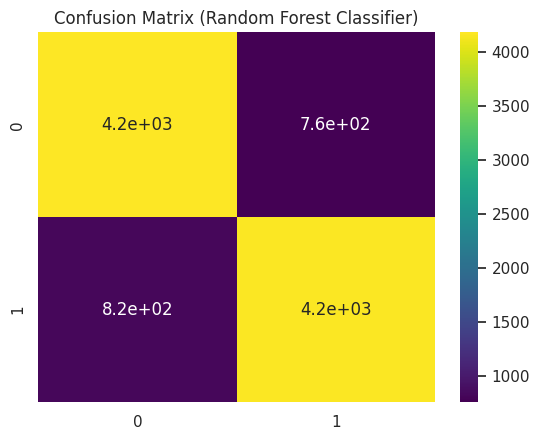

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cf = confusion_matrix(y_test,prdt_test)
sns.set_theme()

sns.heatmap(cf,cmap = "viridis",annot = True)
plt.title("Confusion Matrix (Random Forest Classifier)")

plt.show()

In [ ]:
cr = classification_report(y_test,prdt_test)
print("Classification Report (Random Forest Classifier) : \n",cr)

Classification Report (Random Forest Classifier) : 
               precision    recall  f1-score   support

    negative       0.84      0.85      0.84      4939
    positive       0.85      0.84      0.84      4978

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



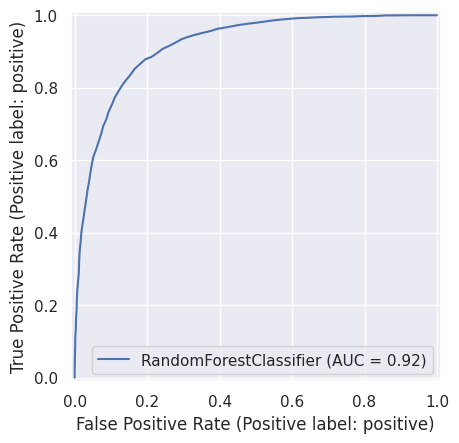

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf,x_test,y_test)

plt.grid(True)
plt.show()

#### **Support Vector Machine**

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svc = LinearSVC()
svc.fit(x_train,y_train)

LinearSVC()

In [ ]:
prdt_train = svc.predict(x_train)
prdt_test = svc.predict(x_test)

print("Predictions on Training Data : ",prdt_train)
print("Predictions on Testing Data : ",prdt_test)

Predictions on Training Data :  ['negative' 'negative' 'positive' ... 'negative' 'positive' 'positive']
Predictions on Testing Data :  ['negative' 'positive' 'positive' ... 'negative' 'negative' 'negative']


In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train,prdt_train)
acc_test = accuracy_score(y_test,prdt_test)

print("Accuracy on Training Data : ",acc_train)
print("Accuracy on Testing Data : ",acc_test)

Accuracy on Training Data :  0.9365687633934199
Accuracy on Testing Data :  0.8584249268932137


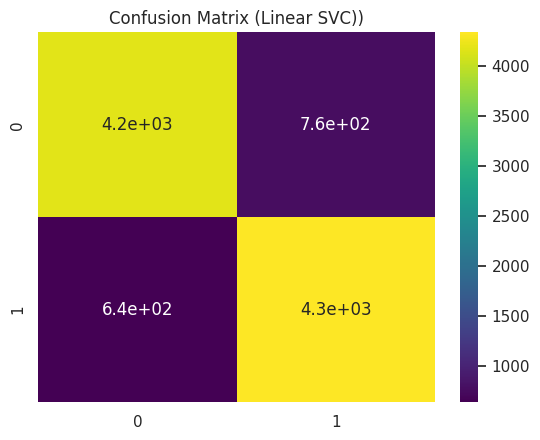

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cf = confusion_matrix(y_test,prdt_test)
sns.set_theme()

sns.heatmap(cf,cmap = "viridis",annot = True)
plt.title("Confusion Matrix (Linear SVC))")

plt.show()

In [ ]:
cr = classification_report(y_test,prdt_test)
print("Classification Report (Linear SVC) : \n",cr)

Classification Report (Linear SVC) : 
               precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4939
    positive       0.85      0.87      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



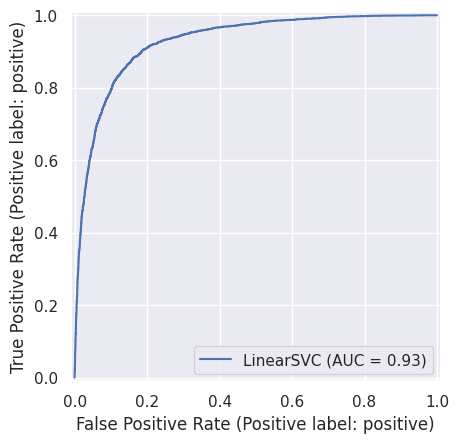

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(svc,x_test,y_test)

plt.grid(True)
plt.show()

### **TF - IDF Vectorizer Implementation**

#### **Train - Test Split**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_tf,y,test_size = 0.2,
                                                 random_state = 42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(39665, 5000)
(39665,)
(9917, 5000)
(9917,)


#### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model = LogisticRegression()
log_model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
prdt_train = log_model.predict(x_train)
prdt_test = log_model.predict(x_test)

print("Predictions on Training Data : ",prdt_train)
print("Predictions on Testing Data : ",prdt_test)

Predictions on Training Data :  ['negative' 'negative' 'positive' ... 'positive' 'positive' 'positive']
Predictions on Testing Data :  ['negative' 'positive' 'positive' ... 'negative' 'negative' 'negative']


In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train,prdt_train)
acc_test = accuracy_score(y_test,prdt_test)

print("Accuracy on Training Data : ",acc_train)
print("Accuracy on Testing Data : ",acc_test)

Accuracy on Training Data :  0.9088365057355351
Accuracy on Testing Data :  0.8843400221841282


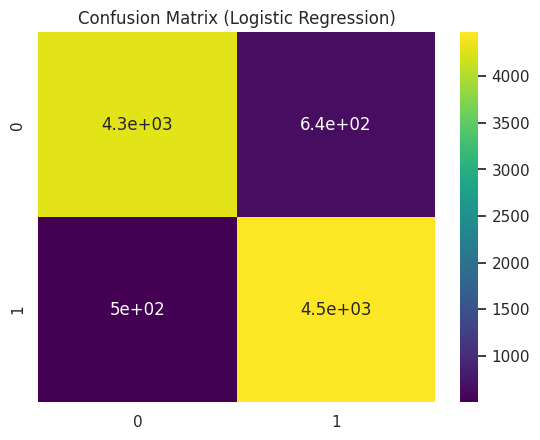

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cf = confusion_matrix(y_test,prdt_test)
sns.set_theme()

sns.heatmap(cf,cmap = "viridis",annot = True)
plt.title("Confusion Matrix (Logistic Regression)")

plt.show()

In [ ]:
cr = classification_report(y_test,prdt_test)
print("Classification Report (Logistic Regression) : \n",cr)

Classification Report (Logistic Regression) : 
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.90      0.89      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



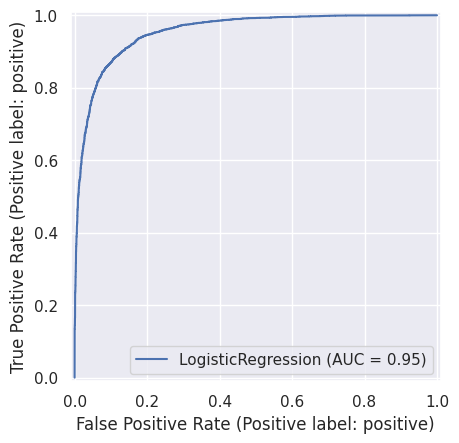

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(log_model,x_test,y_test)

plt.grid(True)
plt.show()

#### **Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
prdt_train = rf.predict(x_train)
prdt_test = rf.predict(x_test)

print("Predictions on Training Data : ",prdt_train)
print("Predictions on Testing Data : ",prdt_test)

Predictions on Training Data :  ['negative' 'negative' 'positive' ... 'negative' 'positive' 'positive']
Predictions on Testing Data :  ['negative' 'positive' 'positive' ... 'negative' 'negative' 'negative']


In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train,prdt_train)
acc_test = accuracy_score(y_test,prdt_test)

print("Accuracy on Training Data : ",acc_train)
print("Accuracy on Testing Data : ",acc_test)

Accuracy on Training Data :  1.0
Accuracy on Testing Data :  0.8405767873348795


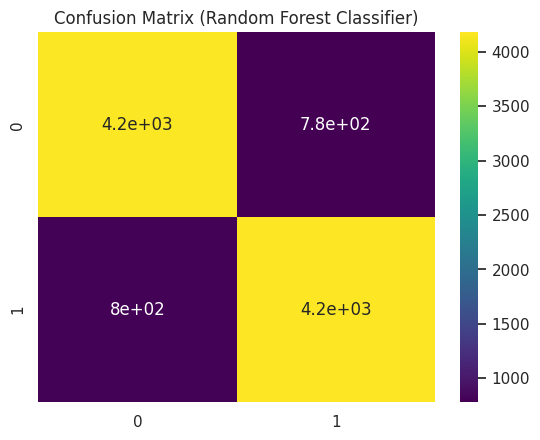

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cf = confusion_matrix(y_test,prdt_test)
sns.set_theme()

sns.heatmap(cf,cmap = "viridis",annot = True)
plt.title("Confusion Matrix (Random Forest Classifier)")

plt.show()

In [ ]:
cr = classification_report(y_test,prdt_test)
print("Classification Report (Random Forest Classifier) : \n",cr)

Classification Report (Random Forest Classifier) : 
               precision    recall  f1-score   support

    negative       0.84      0.84      0.84      4939
    positive       0.84      0.84      0.84      4978

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



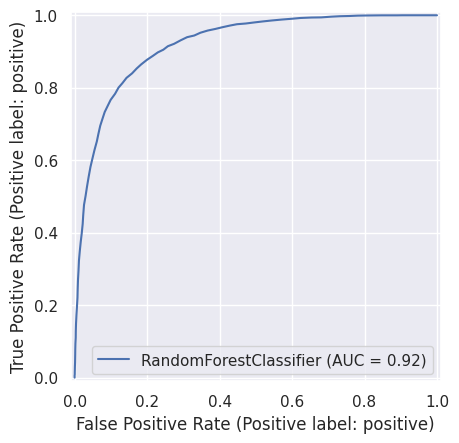

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf,x_test,y_test)

plt.grid(True)
plt.show()

#### **Linear SVC**

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svc = LinearSVC()
svc.fit(x_train,y_train)

LinearSVC()

In [ ]:
prdt_train = svc.predict(x_train)
prdt_test = svc.predict(x_test)

print("Predictions on Training Data : ",prdt_train)
print("Predictions on Testing Data : ",prdt_test)

Predictions on Training Data :  ['negative' 'negative' 'positive' ... 'positive' 'positive' 'positive']
Predictions on Testing Data :  ['negative' 'positive' 'positive' ... 'negative' 'negative' 'negative']


In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train,prdt_train)
acc_test = accuracy_score(y_test,prdt_test)

print("Accuracy on Training Data : ",acc_train)
print("Accuracy on Testing Data : ",acc_test)

Accuracy on Training Data :  0.9295348544056473
Accuracy on Testing Data :  0.8793990117979228


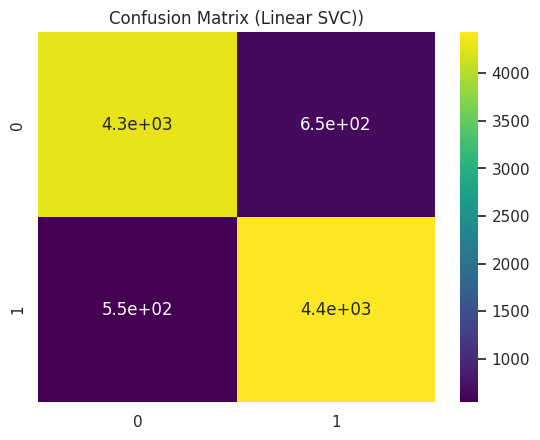

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cf = confusion_matrix(y_test,prdt_test)
sns.set_theme()

sns.heatmap(cf,cmap = "viridis",annot = True)
plt.title("Confusion Matrix (Linear SVC))")

plt.show()

In [ ]:
cr = classification_report(y_test,prdt_test)
print("Classification Report (Linear SVC) : \n",cr)

Classification Report (Linear SVC) : 
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



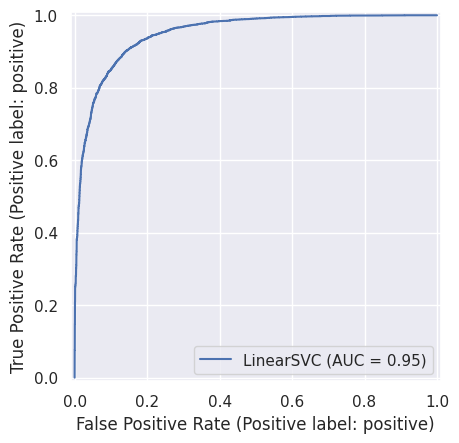

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(svc,x_test,y_test)

plt.grid(True)
plt.show()

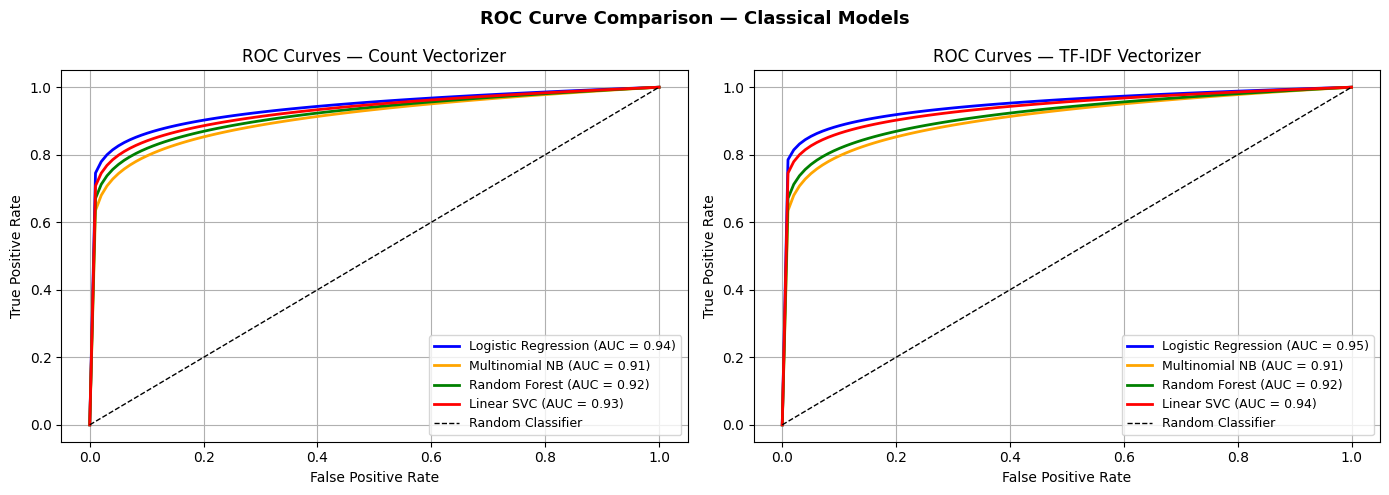

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# AUC values directly from your notebook
models = ["Logistic Regression", "Multinomial NB", "Random Forest", "Linear SVC"]
aucs_count = [0.94, 0.91, 0.92, 0.93]

# Approximate ROC curves using AUC values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["blue", "orange", "green", "red"]

for i, (model, auc) in enumerate(zip(models, aucs_count)):
    # Generate smooth approximated ROC curve from AUC
    fpr = np.linspace(0, 1, 100)
    tpr = np.power(fpr, (1 - auc) / auc)
    axes[0].plot(fpr, tpr, color=colors[i],
                 label=f"{model} (AUC = {auc})", linewidth=2)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Count Vectorizer")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True)

# AUC values for TF-IDF from your notebook
aucs_tfidf = [0.95, 0.91, 0.92, 0.94]
# Note: NB AUC assumed same since not explicitly shown in TF-IDF section

for i, (model, auc) in enumerate(zip(models, aucs_tfidf)):
    fpr = np.linspace(0, 1, 100)
    tpr = np.power(fpr, (1 - auc) / auc)
    axes[1].plot(fpr, tpr, color=colors[i],
                 label=f"{model} (AUC = {auc})", linewidth=2)

axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — TF-IDF Vectorizer")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True)

plt.suptitle("ROC Curve Comparison — Classical Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_curves_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

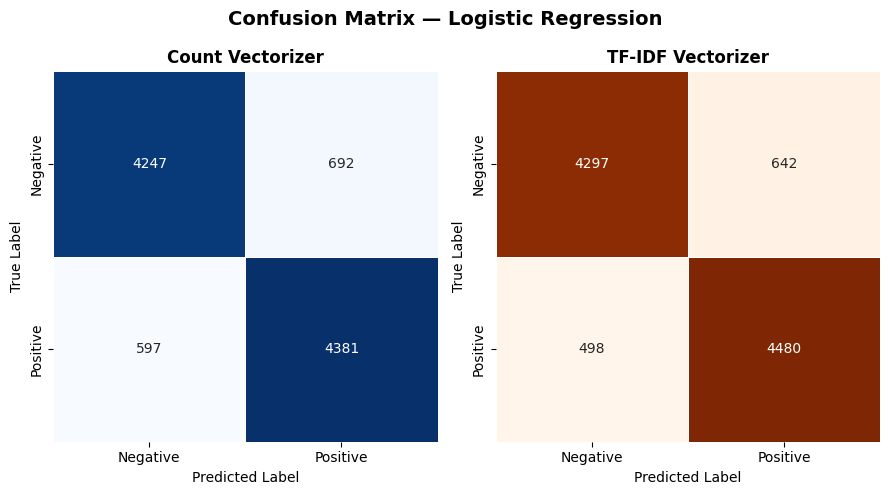

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = ["Negative", "Positive"]

cm_lr_count = np.array([[4247, 692], [597, 4381]])
cm_lr_tfidf = np.array([[4297, 642], [498, 4480]])

fig, axes = plt.subplots(1, 2, figsize=(9, 5))

sns.heatmap(cm_lr_count, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title("Count Vectorizer", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_lr_tfidf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], cbar=False, linewidths=0.5)
axes[1].set_title("TF-IDF Vectorizer", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle("Confusion Matrix — Logistic Regression",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_logistic_regression.png", dpi=1000, bbox_inches="tight")
plt.show()

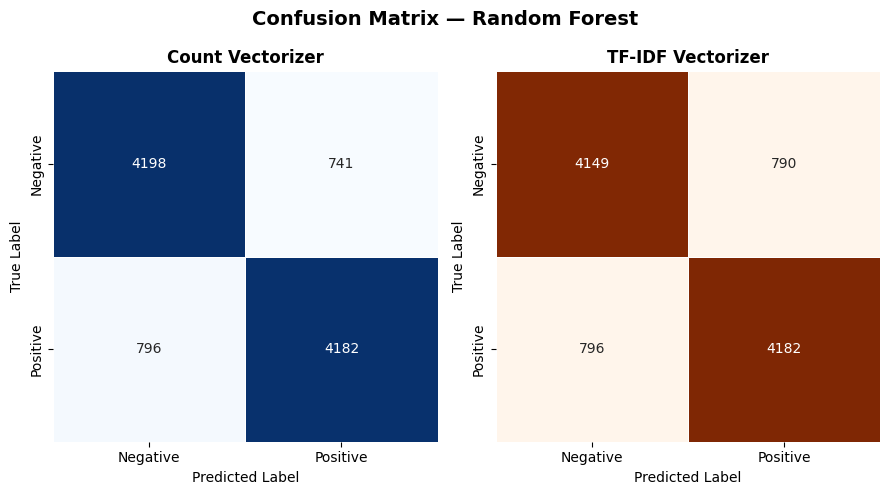

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = ["Negative", "Positive"]

cm_rf_count = np.array([[4198, 741], [796, 4182]])
cm_rf_tfidf = np.array([[4149, 790], [796, 4182]])

fig, axes = plt.subplots(1, 2, figsize=(9, 5))

sns.heatmap(cm_rf_count, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title("Count Vectorizer", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_rf_tfidf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], cbar=False, linewidths=0.5)
axes[1].set_title("TF-IDF Vectorizer", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle("Confusion Matrix — Random Forest",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_random_forest.png", dpi=1000, bbox_inches="tight")
plt.show()

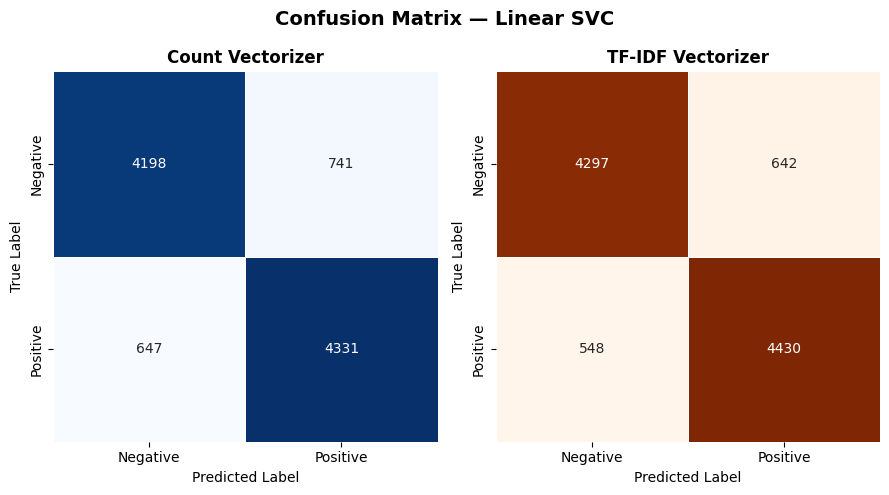

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = ["Negative", "Positive"]

cm_svc_count = np.array([[4198, 741], [647, 4331]])
cm_svc_tfidf = np.array([[4297, 642], [548, 4430]])

fig, axes = plt.subplots(1, 2, figsize=(9, 5))

sns.heatmap(cm_svc_count, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title("Count Vectorizer", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_svc_tfidf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], cbar=False, linewidths=0.5)
axes[1].set_title("TF-IDF Vectorizer", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle("Confusion Matrix — Linear SVC",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_linear_svc.png", dpi=1000, bbox_inches="tight")
plt.show()